##Before we begin i would like to give a special thanks to gorgeous, smart and sexy HSE student from Faculty of Computer Science. He helped me drastically to write this code, also you should check out his work on selenium, where he got 10 for it - https://disk.360.yandex.ru/d/xpTlesyHmDGXmA, i also stole some code from it

Steam Store Scraping

Collecting game data from store.steampowered.com for the project on game popularity factors, basically we want to find what makes game to sell better than other, only taking data from their pages on various websites sixseven.
1. Download individual game pages in parallel (requests + ThreadPoolExecutor)
2. Parse saved HTML locally (bs4 + regex)
3. Clean everything up and export to CSV

also i am using selenium cause i got banned by IP by steam, so i am emulating chrome, and line below is installtion of chrome

That basically all my part



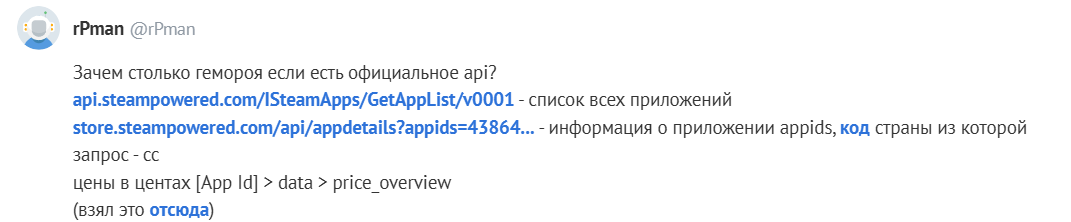

USED WEBSITES FOR STEALING CODE:

https://coder-castrov.vercel.app/blogs/parsing-dannyh-ob-igrah-i-obschego-obzora-otzyvov-s-steam-curator-list-303287e1-614

https://github.com/T0rnik3/Steam_Store_Parsing/blob/master/Parser.py

https://github.com/RandomProgramm3r/Steam-Market-Parser?tab=readme-ov-file#-step-1-clone-the-repository

https://youtu.be/_sgRQzmz6NQ?si=_DIw3TUsRwrmd2_l

https://habr.com/ru/companies/selectel/articles/754674/

https://happypython.ru/2022/11/27/selenium-chromedriver-find-elements/


there was one more website, but is said there that if i am reading that code i help ukraine, and thats illegal 💀

In [1]:
!pip install selenium -q
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get install -y -qq ./google-chrome-stable_current_amd64.deb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 8.5 MB/s eta 0:00:00
Selecting previously unselected package libatk1.0-data.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../00-libatk1.0-data_2.36.0-3build1_all.deb ...
Unpacking libatk1.0-data (2.36.0-3build1) ...
Selecting previously unselected package libatk1.0-0:amd64.
Preparing to unpack .../01-libatk1.0-0_2.36.0-3build1_amd64.deb ...
Unpacking libatk1.0-0:amd64 (2.36.0-3build1) ...
Selecting previously unselected package libatspi2.0-0:amd64.
Preparing to unpack .../02-libatspi2.0-0_2.44.0-3_amd64.deb ...
Unpacking libatspi2.0-0:amd64 (2.44.0-3) ...
Selecting previously unselected package libatk-bridge2.0-0:amd64.
Preparing to unpack .../03-libatk-bridge2.0-0_2.38.0-3_amd64.deb ...
Unpacking libatk-bridge2.0-0:amd64 (2

Here i am importing all libraries that i need

ok so reauest is a simplier version of silenium

beatiful soup is for searching in html using CSS

pandas is for tables

re is for matching and extracting parts from the text(specific ones)

time, is used to not get banned

random has the same function, to not get banned, so i do not look as a bot


json for steam, it is built using java

datetime for parsing aint no way dates

from concurrent.futures import ThreadPoolExecutor, as_completed this libray gpt told me to use, cause it can run multiple applications at ones, and i dont want to wait for 3 hours



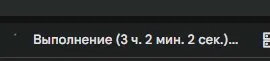

that was my first try on this thing

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time
import random
import json
import os
from random import randint
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed

from selenium import webdriver
from selenium.webdriver.chrome.options import Options

Defines http headers sent with every requests call. The user-agent string tells steam's server "I'm a normal Chrome browser on Windows 10."

cookies for birthday in unix, show me mature content, and return everything in english, cause i am using vpn for tg, and steam might return everything in dutch

In [4]:
HEADERS = {
  "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
}

COOKIES = {
  "birthtime":"568022401",
  "wants_mature_content":"1",
  "Steam_Language":"english",
}

SEARCH_URL= "https://store.steampowered.com/search/results/"

## Setting up Selenium

for this part took code from here: https://www.browserstack.com/guide/selenium-chrome-options

In [5]:
opts = Options()
opts.add_argument("--headless") # this line cause i am writing in colab, i dont want browser window bruh
opts.add_argument("--no-sandbox") # without this line sandbox security will conflict with colab
opts.add_argument("--disable-dev-shm-usage") #chrome might crash without this line

driver = webdriver.Chrome(options=opts)

driver.get("https://store.steampowered.com")
time.sleep(2)
for k, v in COOKIES.items():
  driver.add_cookie({"name": k, "value": v, "domain": "store.steampowered.com"})

driver.title

'Welcome to Steam'

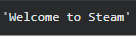


Steam's JSON endpoint
 has a pagination limit, it stops returning results around offset 1500. so yeah, crap, need to use genre by genre approach and selenium, i guess no other way i can imagine

The script iterates through these genres to collect games from each category, which helps get a diverse dataset and avoids steam's pagination limit wich is 1500. so i use dictionary genre_tags

In [6]:
genre_tags = {
  "action": "19","adventure": "21", "rpg": "122",
  "strategy": "9", "simulation": "599", "sports":"701",
  "racing":"699", "indie":"492","casual": "597",
  "puzzle": "1664", "platformer": "1625","shooter": "1774",
  "survival": "1662", "horror":"1667","open_world": "1755",
}

In [7]:
all_games = []
seen = set()#set cause O(1) instead of list o(n)
gayn = 10500

for genre, tag_id in genre_tags.items():# a big ass loop for games and shi
  if len(all_games) >= gayn:
    break
  offset = 0
  cnt = 0
  fails = 0
  while len(all_games) < gayn:
    url = f"{SEARCH_URL}?query=&start={offset}&count=50&sort_by=_ASC&tags={tag_id}&infinite=1"
    driver.get(url)
    time.sleep(1.5)
    try:
      page_soup = BeautifulSoup(driver.page_source, "html.parser")
      pre = page_soup.select_one("pre")
      if not pre:
        break
      payload = json.loads(pre.text)
      html_chunk = payload.get("results_html", "")
    except (json.JSONDecodeError, AttributeError):# one time got this mistake and code broke, so now adding this block
      fails += 1
      if fails >= 3:
        break
      continue
    fails = 0
    rows = BeautifulSoup(html_chunk, "html.parser").select("a.search_result_row")
    if not rows:
      break
    new_on_page = 0
    for row in rows:
      app_id = row.get("data-ds-appid", "")
      if not app_id or app_id in seen:
        continue
      seen.add(app_id)
      title = row.select_one("span.title")
      date_div = row.select_one("div.search_released")
      price_el = row.select_one("div.discount_final_price") or row.select_one("div.search_price")
      review_span = row.select_one("span.search_review_summary")
      pos_pct, num_reviews = None, None
      if review_span:
        tip = review_span.get("data-tooltip-html", "")
        pct_m = re.search(r"(\d+)%", tip)
        cnt_m = re.search(r"([\d,]+)\s+user reviews", tip)# regex is the our savior
        if pct_m: pos_pct = int(pct_m.group(1))
        if cnt_m: num_reviews = int(cnt_m.group(1).replace(",", ""))
      all_games.append({
        "app_id": app_id,
        "name": title.text.strip() if title else "Unknown",
        "release_date": date_div.text.strip() if date_div else "",
        "price": price_el.text.strip() if price_el else "",
        "positive_pct": pos_pct,
        "total_reviews": num_reviews,
      })
      new_on_page += 1
      cnt += 1
    if new_on_page == 0:
      break
    offset += 50
    if offset > 5000:
      break
    time.sleep(random.uniform(0.5, 1.0))
  print(f"{genre}: +{cnt} |{len(all_games)}")
print(f"{len(all_games)}")

action: +4992 |4992
adventure: +2406 |7398
rpg: +2723 |10121
strategy: +384 |10505
10505


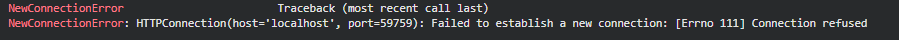

above what i got for waiting 3 hours

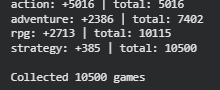

well, i got to many games with 4 starting genres, so i add indie, cause they are on a hype in recent years

 Adding more indie games

Since the target stopped at 4 genres, we specifically pull from the indie tag to ensure good coverage for our business question.

In [8]:
indie_added = 0
offset = 0
while indie_added < 1000:
  url = f"{SEARCH_URL}?query=&start={offset}&count=50&sort_by=_ASC&tags=492&infinite=1"
  driver.get(url)
  time.sleep(1.5)
  try:
    page_soup = BeautifulSoup(driver.page_source, "html.parser")
    pre = page_soup.select_one("pre")
    if not pre: break
    html_chunk = json.loads(pre.text).get("results_html", "")
  except:
    break
  rows = BeautifulSoup(html_chunk, "html.parser").select("a.search_result_row")
  if not rows: break
  for row in rows:
    app_id = row.get("data-ds-appid", "")
    if not app_id or app_id in seen: continue
    seen.add(app_id)
    title = row.select_one("span.title")
    date_div = row.select_one("div.search_released")
    price_el = row.select_one("div.discount_final_price") or row.select_one("div.search_price")
    review_span = row.select_one("span.search_review_summary")
    pos_pct, num_reviews = None, None
    if review_span:
      tip = review_span.get("data-tooltip-html", "")
      pct_m = re.search(r"(\d+)%", tip)
      cnt_m = re.search(r"([\d,]+)\s+user reviews", tip)
      if pct_m: pos_pct = int(pct_m.group(1))
      if cnt_m: num_reviews = int(cnt_m.group(1).replace(",", ""))
    all_games.append({
      "app_id": app_id,
      "name": title.text.strip() if title else "Unknown",
      "release_date": date_div.text.strip() if date_div else "",
      "price": price_el.text.strip() if price_el else "",
      "positive_pct": pos_pct,
      "total_reviews": num_reviews,
    })
    indie_added += 1
  offset += 50
  if offset > 3000: break
  time.sleep(random.uniform(0.5, 1.0))

print(f"{indie_added}, {len(all_games)}")

711, 11216


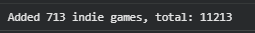

just visualisation for me

In [9]:
df_search = pd.DataFrame(all_games)
df_search.to_csv("steam_search_raw.csv", index=False)
df_search.head()

,app_id,name,release_date,price,positive_pct,total_reviews
0,730,Counter-Strike 2,"Aug 21, 2012",Free,86.0,2505143.0
1,3321460,Crimson Desert,"Mar 19, 2026",$69.99,75.0,17177.0
2,3764200,Resident Evil Requiem,"Feb 27, 2026",$69.99,96.0,43204.0
3,1808500,ARC Raiders,"Oct 30, 2025",$31.99,86.0,179120.0
4,3065800,Marathon,"Mar 5, 2026",$39.99,89.0,22683.0


Downloading game pages in parallel

Each game has its own page at steam with tags, description, and other shi. We download all pages to disk using 10 threads so we can parse them locally without making more requests.

In [10]:
os.makedirs("html_pages", exist_ok=True)
def grab_page(app_id):
  path = f"html_pages/{app_id}.html"
  if os.path.exists(path):
    return app_id, True
  try:
    r = requests.get(f"https://store.steampowered.com/app/{app_id}/", headers=HEADERS, cookies=COOKIES, timeout=10)
    if r.status_code == 200:
      with open(path, "w", encoding="utf-8") as f:
        f.write(r.text)
      return app_id, True
  except:
    pass
  return app_id, False
app_ids = [g["app_id"] for g in all_games]#list of id to download
downloaded, failed = 0, 0
with ThreadPoolExecutor(max_workers=10) as pool: #idea that i stole from one forum, reddit it was, i guess and chat gpt teached me how to write it
  futures = {pool.submit(grab_page, aid): aid for aid in app_ids}
  for fut in as_completed(futures):
    _, ok = fut.result()
    if ok: downloaded += 1
    else: failed += 1
    if (downloaded + failed) % 500 == 0:
      print(f" {downloaded} | {failed} | {downloaded+failed}/{len(app_ids)}") #just a progress bar for me

print(f" {downloaded},{failed}")

 500 | 0 | 500/11216
 1000 | 0 | 1000/11216
 1500 | 0 | 1500/11216
 2000 | 0 | 2000/11216
 2500 | 0 | 2500/11216
 3000 | 0 | 3000/11216
 3500 | 0 | 3500/11216
 4000 | 0 | 4000/11216
 4500 | 0 | 4500/11216
 5000 | 0 | 5000/11216
 5500 | 0 | 5500/11216
 6000 | 0 | 6000/11216
 6500 | 0 | 6500/11216
 7000 | 0 | 7000/11216
 7500 | 0 | 7500/11216
 8000 | 0 | 8000/11216
 8500 | 0 | 8500/11216
 9000 | 0 | 9000/11216
 9500 | 0 | 9500/11216
 10000 | 0 | 10000/11216
 10500 | 0 | 10500/11216
 11000 | 0 | 11000/11216
 11216,0


Parsing saved HTML locally

Now we parse all the HTML files from disk thank god it much faster. We extract description, user tags, genres, developer, and review stats using BeautifulSoup + regex.

In [11]:
details = {}
html_files = os.listdir("html_pages")

for i, fname in enumerate(html_files):#enumerate is used to get ids for progress
  app_id = fname.replace(".html", "")#no neead for ".html"
  with open(f"html_pages/{fname}", "r", encoding="utf-8") as f:
    soup = BeautifulSoup(f.read(), "html.parser")
  desc_el = soup.select_one("div.game_description_snippet")
  tag_els = soup.select("a.app_tag")
  dev_el = soup.select_one("div#developers_list")
  genre_names = []
  genre_block = soup.select_one("div#genresAndManufacturer")
  if genre_block:
    genre_names= [a.text.strip() for a in genre_block.select("span a") if "/genre/" in a.get("href", "")]
  review_label, rev_pct, rev_count = "", None, None
  for rev_row in soup.select(".user_reviews_summary_row"):
    if "All Reviews" in rev_row.text:
      lbl = rev_row.select_one(".game_review_summary")
      if lbl: review_label = lbl.text.strip()
      m = re.search(r"\((\d+)%\s+of\s+([\d,]+)\)", rev_row.text)#searches the row's text for a pattern like "(82% of 1,234)"
      if m:
        rev_pct = int(m.group(1))
        rev_count = int(m.group(2).replace(",", ""))
      break
  details[app_id] = {
    "short_description": desc_el.text.strip() if desc_el else "",
    "tags": ", ".join(t.text.strip() for t in tag_els),
    "genres": ", ".join(genre_names),
    "developer": dev_el.text.strip() if dev_el else "",
    "review_label": review_label,
    "detail_pct": rev_pct,
    "detail_reviews": rev_count,
  }

  if (i + 1) % 2000 == 0:
    print(f"parsed {i+1}/{len(html_files)}")

print(len(details))
print(sum(1 for d in details.values() if d['short_description']))#with description
print(sum(1 for d in details.values() if d['tags']))#with tags


parsed 2000/11216
parsed 4000/11216
parsed 6000/11216
parsed 8000/11216
parsed 10000/11216
11216
8604
11216


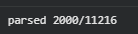

different number of all games cause again got banned for multiple requests, while debugging, the scr shows just the part of the progress

Merging and the dataset, finally

In [12]:
rows = []
for g in all_games:
  d = details.get(g["app_id"], {})
  rows.append({
    "app_id": g["app_id"],
    "name": g["name"],
    "release_date": g["release_date"],
    "price": g["price"],
    "positive_pct": d.get("detail_pct") or g.get("positive_pct"),
    "total_reviews": d.get("detail_reviews") or g.get("total_reviews"),
    "review_label": d.get("review_label", ""),
    "short_description": d.get("short_description", ""),
    "tags": d.get("tags", ""),
    "genres": d.get("genres", ""),
    "developer": d.get("developer", ""),
  })
df = pd.DataFrame(rows)
df.shape

(11216, 11)

 Data cleaning with regex

In [13]:
def clean_price(raw):
  if not raw or not isinstance(raw, str): return None
  raw = raw.strip()
  if re.match(r"(?i)(free|f2p)", raw): return 0.0
  nums = re.sub(r"[^\d.,]", "", raw)
  if not nums: return None
  if "," in nums and "." in nums:
    if nums.index(",") < nums.index("."):
      nums = nums.replace(",", "")
    else:
      nums = nums.replace(".", "").replace(",", ".")
  elif "," in nums:
    parts = nums.split(",")
    nums = nums.replace(",", ".") if len(parts) == 2 and len(parts[1]) == 2 else nums.replace(",", "")
  try: return round(float(nums), 2)
  except: return None
def parse_date(raw):
  if not raw or not isinstance(raw, str): return None, None
  raw = raw.strip()
  if re.match(r"(?i)(coming|to be|tba|tbd)", raw): return None, None
  for fmt in ["%b %d, %Y", "%d %b, %Y", "%b %d %Y", "%d %b %Y", "%b %Y", "%B %Y"]:
    try:
      dt = datetime.strptime(raw, fmt)
      return dt.strftime("%Y-%m-%d"), dt.year
    except ValueError:
      continue
  yr = re.search(r"((?:19|20)\d{2})", raw)
  return (None, int(yr.group(1))) if yr else (None, None)
def clean_text(txt):
  if not txt: return ""
  txt = re.sub(r"<[^>]+>", " ", txt)
  txt = re.sub(r"[\u200b\u200e\u200f\xa0]", " ", txt)
  txt = re.sub(r"https?://\S+", "", txt)
  return re.sub(r"\s+", " ", txt).strip()

In [15]:
df["price_clean"] = df["price"].apply(clean_price)
df[["date_clean", "year"]] = df["release_date"].apply(lambda x: pd.Series(parse_date(x)))
df["short_description"] = df["short_description"].apply(clean_text)
df["developer"] = df["developer"].apply(clean_text)

print(f"Prices parsed: {df['price_clean'].notna().sum()}/{len(df)}")
print(f"Free games: {(df['price_clean'] == 0).sum()}")
print(f"Dates parsed: {df['date_clean'].notna().sum()}/{len(df)}")

Prices parsed: 11187/11216
Free games: 489
Dates parsed: 11205/11216


In [16]:
df[["name", "price", "price_clean", "release_date", "date_clean", "year"]].head(10)#quality check side by side comparison

,name,price,price_clean,release_date,date_clean,year
0,Counter-Strike 2,Free,0.00,"Aug 21, 2012",2012-08-21,2012.0
1,Crimson Desert,$69.99,69.99,"Mar 19, 2026",2026-03-19,2026.0
2,Resident Evil Requiem,$69.99,69.99,"Feb 27, 2026",2026-02-27,2026.0
3,ARC Raiders,$31.99,31.99,"Oct 30, 2025",2025-10-30,2025.0
4,Marathon,$39.99,39.99,"Mar 5, 2026",2026-03-05,2026.0
5,Marvel Rivals,Free,0.00,"Dec 6, 2024",2024-12-06,2024.0
6,HELLDIVERS™ 2,$29.99,29.99,"Feb 8, 2024",2024-02-08,2024.0
7,Ready or Not,$24.99,24.99,"Dec 13, 2023",2023-12-13,2023.0
8,DEATH STRANDING 2: ON THE BEACH,$69.99,69.99,"Mar 19, 2026",2026-03-19,2026.0
9,Cyberpunk 2077,$20.99,20.99,"Dec 10, 2020",2020-12-10,2020.0


Exporting final dataset, i stole code from chat gpt, cause i had no idie how to do this

In [17]:
steam_df = df[[
  "app_id", "name", "date_clean", "year",
  "price_clean", "positive_pct", "total_reviews", "review_label",
  "short_description", "tags", "genres", "developer"
]].rename(columns={"date_clean": "release_date", "year": "release_year", "price_clean": "price"})

steam_df.to_csv("steam_games_dataset.csv", index=False)

print(len(steam_df))#rows
print(list(steam_df.columns))#columns
print(steam_df.isnull().sum())#missing values
steam_df.head()

11216
['app_id', 'name', 'release_date', 'release_year', 'price', 'positive_pct', 'total_reviews', 'review_label', 'short_description', 'tags', 'genres', 'developer']
app_id                0
name                  0
release_date         11
release_year         11
price                29
positive_pct         21
total_reviews        21
review_label          0
short_description     0
tags                  0
genres                0
developer             0
dtype: int64


,app_id,name,release_date,release_year,price,positive_pct,total_reviews,review_label,short_description,tags,genres,developer
0,730,Counter-Strike 2,2012-08-21,2012.0,0.00,86.0,2505143.0,Very Positive,"For over two decades, Counter-Strike has offer...","FPS, Shooter, Multiplayer, Competitive, Action...","Action, Free To Play",Valve
1,3321460,Crimson Desert,2026-03-19,2026.0,69.99,75.0,17177.0,Mostly Positive,Crimson Desert is an open-world action-adventu...,"Action, Open World, Singleplayer, Adventure, E...","Action, Adventure",Pearl Abyss
2,3764200,Resident Evil Requiem,2026-02-27,2026.0,69.99,96.0,43204.0,Overwhelmingly Positive,Requiem for the dead. Nightmare for the living...,"Survival Horror, Zombies, Horror, Third-Person...","Action, Adventure","CAPCOM Co., Ltd."
3,1808500,ARC Raiders,2025-10-30,2025.0,31.99,86.0,179120.0,Very Positive,ARC Raiders is a multiplayer extraction advent...,"Extraction Shooter, Multiplayer, PvE, PvP, Thi...",Action,Embark Studios
4,3065800,Marathon,2026-03-05,2026.0,39.99,89.0,22683.0,Very Positive,Scavenge the lost colony of Tau Ceti IV as a b...,"Extraction Shooter, PvP, Multiplayer, Sci-fi, ...",Action,Bungie


final countdown

In [18]:
print(steam_df['short_description'].ne('').sum())
print(steam_df['tags'].ne('').sum())
print(steam_df['total_reviews'].notna().sum())
print(steam_df['genres'].ne('').sum())
print(steam_df["review_label"].value_counts())
print(steam_df["release_year"].value_counts().head(10))

8604
11216
11195
11190
review_label
Very Positive              6175
Mostly Positive            1794
Mixed                      1323
Overwhelmingly Positive    1075
Positive                    779
Mostly Negative              42
                             15
Very Negative                 5
8 user reviews                2
1 user reviews                2
5 user reviews                2
Overwhelmingly Negative       2
Name: count, dtype: int64
release_year
2025.0    2261
2024.0    1498
2023.0    1124
2022.0     855
2026.0     775
2021.0     766
2020.0     708
2019.0     572
2018.0     501
2017.0     463
Name: count, dtype: int64


In [19]:
from google.colab import files
files.download("steam_games_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>